In [1]:
import pandas as pd
df = pd.read_csv('retail_sales_data.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Discount Range,Discount Bucket,Profit,Order Month
0,1,CA-2016-152156,08-11-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,No Discount,0%,41.9136,Nov-2016
1,2,CA-2016-152156,08-11-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,No Discount,0%,219.5820,Nov-2016
2,3,CA-2016-138688,12-06-2016,16-06-2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,No Discount,0%,6.8714,Jun-2016
3,4,US-2015-108966,11-10-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,Above 40%,31%+,-383.0310,Oct-2015
4,5,US-2015-108966,11-10-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,11-20%,11-20%,2.5164,Oct-2015


In [3]:
import numpy as np
def bucket_discount(d):
  if d == 0:
    return '0%'
  elif d<= 0.10:
    return '1-10%'
  elif d<= 0.20:
    return '11-20%'
  elif d<= 0.30:
    return '21-30%'
  else:
    return '31%+'
df['Discount_Bucket'] = df['Discount'].apply(bucket_discount)
summary = df.groupby('Discount_Bucket').agg(total_sales=('Sales', 'sum'),total_profit=('Profit', 'sum')).round(2)
bucket_order = ['0%', '1-10%', '11-20%', '21-30%', '31%+']
summary = summary.reindex(bucket_order)
summary


,total_sales,total_profit
Discount_Bucket,,
0%,1087908.47,320987.60
1-10%,54369.35,9029.18
11-20%,792152.89,91756.30
21-30%,103226.66,-10369.28
31%+,259543.49,-125006.78


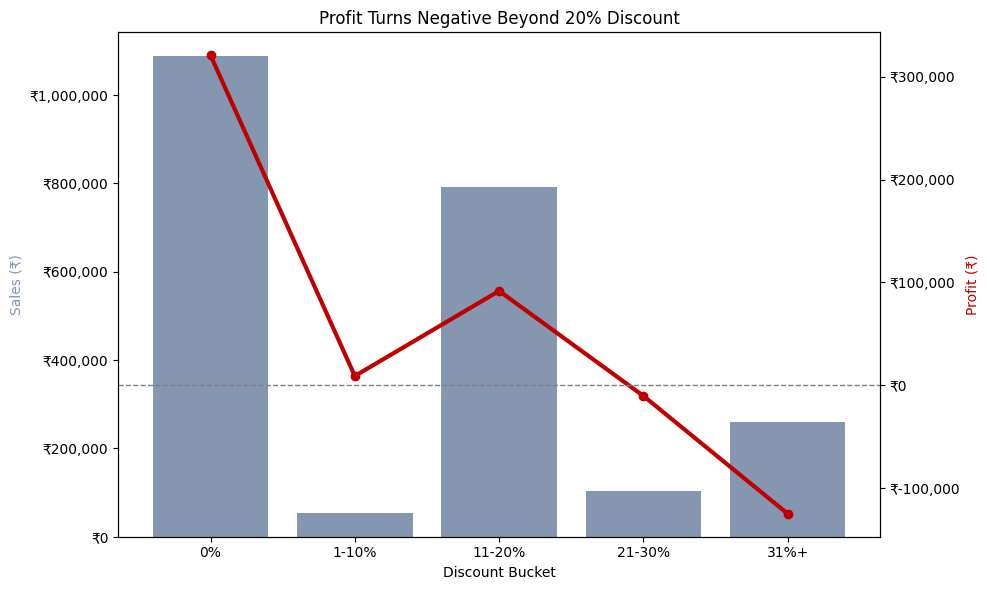

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(summary.index, summary['total_sales'], color='#8496B0', label='Sales')
ax1.set_xlabel('Discount Bucket')
ax1.set_ylabel('Sales (₹)', color='#8496B0')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

ax2 = ax1.twinx()
ax2.plot(summary.index, summary['total_profit'], color='#C00000', marker='o', linewidth=3, label='Profit')
ax2.set_ylabel('Profit (₹)', color='#C00000')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax2.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.title('Profit Turns Negative Beyond 20% Discount')
fig.tight_layout()
plt.show()

In [7]:
from scipy import stats

df['Profit_Margin'] = df['Profit'] / df['Sales']

# drop any rows with missing or infinite values before correlating
clean_df = df[['Discount', 'Profit_Margin']].replace([float('inf'), -float('inf')], pd.NA).dropna()

correlation, p_value = stats.pearsonr(clean_df['Discount'], clean_df['Profit_Margin'])

print(f"Correlation between Discount and Profit Margin: {correlation:.3f}")
print(f"P-value: {p_value:.5f}")

if p_value < 0.05:
    print("This relationship is statistically significant.")
else:
    print("This relationship is not statistically significant.")

Correlation between Discount and Profit Margin: -0.864
P-value: 0.00000
This relationship is statistically significant.


## Summary

Analyzed 5,009 retail orders to understand why profit margin (12.47%) lagged behind strong sales.

**Finding:** Discounts above 20% turn profit negative, despite stable sales volume. Furniture is hit hardest, losing more profit than any other category at high discount levels.

**Statistical validation:** Discount and profit margin show a strong negative correlation (r = -0.864, p < 0.001), confirming this isn't a coincidence.

**Recommendation:** Cap discounts at 20% to protect margins.

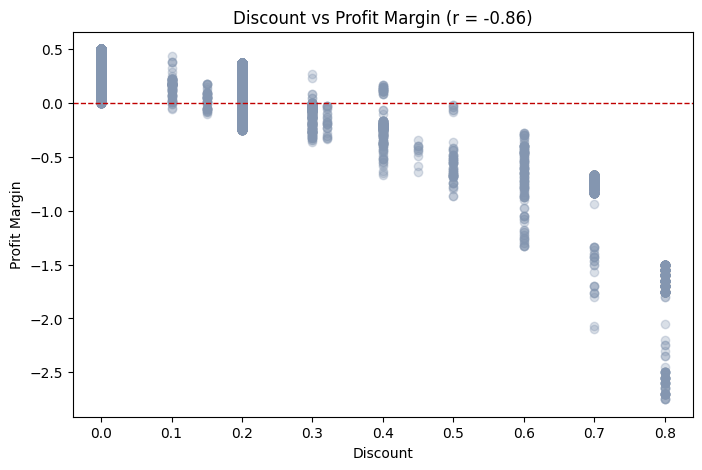

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(clean_df['Discount'], clean_df['Profit_Margin'], alpha=0.3, color='#8496B0')
plt.axhline(0, color='#C00000', linestyle='--', linewidth=1)
plt.xlabel('Discount')
plt.ylabel('Profit Margin')
plt.title(f'Discount vs Profit Margin (r = {correlation:.2f})')
plt.show()